In [1]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [7]:
"""Multi-agent supervisor for coordinating research across multiple specialized agents.

This module implements a supervisor pattern where:
1. A supervisor agent coordinates research activities and delegates tasks
2. Multiple researcher agents work on specific sub-topics independently
3. Results are aggregated and compressed for final reporting

The supervisor uses parallel research execution to improve efficiency while
maintaining isolated context windows for each research topic.
"""

import asyncio

from typing_extensions import Literal

from langchain_core.messages import (
    HumanMessage, 
    BaseMessage, 
    SystemMessage, 
    ToolMessage,
    filter_messages
)
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from langchain_google_genai import ChatGoogleGenerativeAI
# from langchain_anthropic import ChatAnthropic

from deep_research.prompt import lead_researcher_prompt
from deep_research.agents import research_agent
from deep_research.state import SupervisorState, ConductResearch, ResearchComplete

from deep_research.utils import get_today_str, think_tool

In [8]:
# Ensure async compatibility for Jupyter environments
try:
    import nest_asyncio
    # Only apply if running in Jupyter/IPython environment
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            nest_asyncio.apply()
    except ImportError:
        pass  # Not in Jupyter, no need for nest_asyncio
except ImportError:
    pass  # nest_asyncio not available, proceed without it

In [9]:
def get_notes_from_tool_calls(messages: list[BaseMessage]) -> list[str]:
    """Extract research notes from ToolMessage objects in supervisor message history.
    
    This function retrieves the compressed research findings that sub-agents
    return as ToolMessage content. When the supervisor delegates research to
    sub-agents via ConductResearch tool calls, each sub-agent returns its
    compressed findings as the content of a ToolMessage. This function
    extracts all such ToolMessage content to compile the final research notes.
    
    Args:
        messages: List of messages from supervisor's conversation history
        
    Returns:
        List of research note strings extracted from ToolMessage objects
    """
    return [tool_msg.content for tool_msg in filter_messages(messages, include_types="tool")]

In [19]:
os.environ.pop("GOOGLE_API_KEY", None)

''

In [20]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

In [28]:
supervisor_tools = [ConductResearch, ResearchComplete, think_tool]

# supervisor_model = ChatAnthropic(
#     model="claude-haiku-4-5-20251001",
#     temperature=0.7,
#     max_tokens=32000)
supervisor_model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
    max_tokens=32000)


supervisor_model_with_tools = supervisor_model.bind_tools(supervisor_tools)

In [29]:
# System constants

# Maximum number of tool call iterations for individual researcher agents
# This prevents infinite loops and controls research depth per topic
max_researcher_iterations = 6 # Calls to think_tool + ConductResearch

# Maximum number of concurrent research agents the supervisor can launch
# This is passed to the lead_researcher_prompt to limit parallel research tasks
max_concurrent_researchers = 3

In [30]:
async def supervisor(state: SupervisorState) -> Command[Literal["supervisor_tools"]]:
    """Coordinate research activities.
    
    Analyzes the research brief and current progress to decide:
    - What research topics need investigation
    - Whether to conduct parallel research
    - When research is complete
    
    Args:
        state: Current supervisor state with messages and research progress
        
    Returns:
        Command to proceed to supervisor_tools node with updated state
    """
    supervisor_messages = state.get("supervisor_messages", [])
    
    # Prepare system message with current date and constraints
    system_message = lead_researcher_prompt.format(
        date=get_today_str(), 
        max_concurrent_research_units=max_concurrent_researchers,
        max_researcher_iterations=max_researcher_iterations
    )
    messages = [SystemMessage(content=system_message)] + supervisor_messages
    
    # Make decision about next research steps
    response = await supervisor_model_with_tools.ainvoke(messages)
    
    return Command(
        goto="supervisor_tools",
        update={
            "supervisor_messages": [response],
            "research_iterations": state.get("research_iterations", 0) + 1
        }
    )

In [31]:
async def supervisor_tools(state: SupervisorState) -> Command[Literal["supervisor", "__end__"]]:
    """Execute supervisor decisions - either conduct research or end the process.
    
    Handles:
    - Executing think_tool calls for strategic reflection
    - Launching parallel research agents for different topics
    - Aggregating research results
    - Determining when research is complete
    
    Args:
        state: Current supervisor state with messages and iteration count
        
    Returns:
        Command to continue supervision, end process, or handle errors
    """
    supervisor_messages = state.get("supervisor_messages", [])
    research_iterations = state.get("research_iterations", 0)
    most_recent_message = supervisor_messages[-1]
    
    # Initialize variables for single return pattern
    tool_messages = []
    all_raw_notes = []
    next_step = "supervisor"  # Default next step
    should_end = False
    
    # Check exit criteria first
    exceeded_iterations = research_iterations >= max_researcher_iterations
    no_tool_calls = not most_recent_message.tool_calls
    research_complete = any(
        tool_call["name"] == "ResearchComplete" 
        for tool_call in most_recent_message.tool_calls
    )
    
    if exceeded_iterations or no_tool_calls or research_complete:
        should_end = True
        next_step = END
    else:
        # Execute ALL tool calls before deciding next step
        try:
            # Separate think_tool calls from ConductResearch calls
            think_tool_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "think_tool"
            ]
            
            conduct_research_calls = [
                tool_call for tool_call in most_recent_message.tool_calls 
                if tool_call["name"] == "ConductResearch"
            ]

            # Handle think_tool calls (synchronous)
            for tool_call in think_tool_calls:
                observation = think_tool.invoke(tool_call["args"])
                tool_messages.append(
                    ToolMessage(
                        content=observation,
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    )
                )

            # Handle ConductResearch calls (asynchronous)
            if conduct_research_calls:
                # Launch parallel research agents
                coros = [
                    researcher_agent.ainvoke({
                        "researcher_messages": [
                            HumanMessage(content=tool_call["args"]["research_topic"])
                        ],
                        "research_topic": tool_call["args"]["research_topic"]
                    }) 
                    for tool_call in conduct_research_calls
                ]

                # Wait for all research to complete
                tool_results = await asyncio.gather(*coros)

                # Format research results as tool messages
                # Each sub-agent returns compressed research findings in result["compressed_research"]
                # We write this compressed research as the content of a ToolMessage, which allows
                # the supervisor to later retrieve these findings via get_notes_from_tool_calls()
                research_tool_messages = [
                    ToolMessage(
                        content=result.get("compressed_research", "Error synthesizing research report"),
                        name=tool_call["name"],
                        tool_call_id=tool_call["id"]
                    ) for result, tool_call in zip(tool_results, conduct_research_calls)
                ]
                
                tool_messages.extend(research_tool_messages)

                # Aggregate raw notes from all research
                all_raw_notes = [
                    "\n".join(result.get("raw_notes", [])) 
                    for result in tool_results
                ]
                
        except Exception as e:
            print(f"Error in supervisor tools: {e}")
            should_end = True
            next_step = END
    
    # Single return point with appropriate state updates
    if should_end:
        return Command(
            goto=next_step,
            update={
                "notes": get_notes_from_tool_calls(supervisor_messages),
                "research_brief": state.get("research_brief", "")
            }
        )
    else:
        return Command(
            goto=next_step,
            update={
                "supervisor_messages": tool_messages,
                "raw_notes": all_raw_notes
            }
        )


In [32]:
supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node("supervisor", supervisor)
supervisor_builder.add_node("supervisor_tools", supervisor_tools)
supervisor_builder.add_edge(START, "supervisor")
supervisor_agent = supervisor_builder.compile()

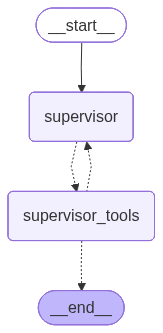

In [33]:
from IPython.display import Image, display

# Show the agent
display(Image(supervisor_agent.get_graph(xray=True).draw_mermaid_png()))

In [34]:
from utils import format_messages
from langchain_core.messages import HumanMessage

research_brief = """I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total number of championship trophies won and the overall win percentage. 
Please research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently completed season. 
The final output should be a comparative analysis that ranks or lists all teams based on both their total number of IPL titles and their all-time win percentage. 
Please use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics sites like ESPNcricinfo for data."""

result = await supervisor_agent.ainvoke({"supervisor_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['supervisor_messages'])

Error in supervisor tools: name 'researcher_agent' is not defined


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total       │
│ number of championship trophies won and the overall win percentage.                                             │
│ Please research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently │
│ completed season.                                                                                               │
│ The final output should be a comparative analysis that ranks or lists all teams based on both their total       │
│ number of IPL titles and their all-time win percentage.                                                         │
│ Please use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics  │
│ sites like ESPNcricinfo for data..                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I need to conduct research to determine the best Indian Premier League (IPL) team. This        │
│ requires gathering two key metrics for all IPL teams, including defunct ones, from 2008 to the most recently    │
│ completed season: total championship trophies won and overall win percentage. I will delegate this              │
│ comprehensive research to a single sub-agent, emphasizing the need for official and reputable sources like      │
│ iplt20.com or ESPNcricinfo. After the research, I will assess if all the required data has been collected       │
│ before proceeding to mark the research as complete."                                                            │
│ }                                                                                                               │
│    ID: d87670ce-d912-40a4-a87c-6c952e21b7f6                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I need to conduct research to determine the best Indian Premier League (IPL) team. This    │
│ requires gathering two key metrics for all IPL teams, including defunct ones, from 2008 to the most recently    │
│ completed season: total championship trophies won and overall win percentage. I will delegate this              │
│ comprehensive research to a single sub-agent, emphasizing the need for official and reputable sources like      │
│ iplt20.com or ESPNcricinfo. After the research, I will assess if all the required data has been collected       │
│ before proceeding to mark the research as complete.                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: ConductResearch                                                                                   │
│    Args: {                                                                                                      │
│   "research_topic": "Research all Indian Premier League (IPL) teams, including those that are defunct, from the │
│ league's inception in 2008 up to and including the most recently completed season. For each team, identify the  │
│ total number of IPL championship trophies won and their all-time overall win percentage. Ensure to use official │
│ sources such as the IPL's official website (iplt20.com) or highly reputable sports statistics websites like     │
│ ESPNcricinfo to collect this data. The final output should provide a clear list of all teams with their         │
│ respective championship titles and win percentages."                                                            │
│ }                                                                                                               │
│    ID: 621cba02-671d-4b27-8c3b-b3529fcefdb7                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯